<a href="https://colab.research.google.com/github/ayesha-tubassum/food-delivery-analytics-Hackathon-project/blob/main/Food_Delivery_Analytics_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**🍔 Food Delivery Analytics Challenge**
### **AI & Data Science Hackathon — Task A**

---

## 📌 **Objective**
This project analyzes 38,964 food delivery records to uncover key patterns in delivery time, traffic, weather, and distance — helping the business make data-driven decisions to improve delivery performance.

## 📂 **Dataset Overview**
The dataset contains 22 columns covering delivery-person details, location, timing, weather, traffic, and delivery outcomes.

## 🛠️ **Tools & Technologies**
Python, Pandas, Matplotlib/Plotly, Streamlit, and Groq AI API for business-friendly explanations.

## 🗂️ **Table of Contents**
1. Load & Understand the Data  
2. Data Cleaning  
3. Basic Statistical Analysis  
4. Answering the Competition Questions  
5. Visualizations  
6. Business Insights  
7. AI-Powered Explanation (Groq API)  
8. Conclusion & Summary

---

# **STEP # 1 Import libraries**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **STEP # 2 Data Loading**

In [2]:
df = pd.read_csv('food_delivery_dataset.csv')

# **STEP # 3 Data Understanding**

In [3]:
print("--- FIRST 5 ROWS ---")
display(df.head())

--- FIRST 5 ROWS ---


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [4]:
print("\n--- DATASET SHAPE (Rows, Columns) ---")
print(df.shape)


--- DATASET SHAPE (Rows, Columns) ---
(38964, 22)


In [5]:
print("\n--- COLUMN DATA TYPES ---")
print(df.dtypes)


--- COLUMN DATA TYPES ---
ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
distance_km                    float64
delivery_speed                  object
dtype: object


In [6]:
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())


--- MISSING VALUES PER COLUMN ---
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1019
Delivery_person_Ratings        1055
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                     835
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
distance_km                       0
delivery_speed                    0
dtype: int64


In [7]:
print("\n--- DUPLICATE ROWS COUNT ---")
print(df.duplicated().sum())


--- DUPLICATE ROWS COUNT ---
0


# **STEP # 4 Data Cleaning**

In [8]:
df_clean = df.copy()

In [10]:
median_age = df_clean['Delivery_person_Age'].median()           #-----we are filling null value of this column with median
df_clean['Delivery_person_Age'].fillna(median_age, inplace=True)

/tmp/ipykernel_2534/2386981423.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Delivery_person_Age'].fillna(median_age, inplace=True)


In [11]:
median_rating = df_clean['Delivery_person_Ratings'].median()
df_clean['Delivery_person_Ratings'].fillna(median_rating, inplace=True)

/tmp/ipykernel_2534/2308678592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Delivery_person_Ratings'].fillna(median_rating, inplace=True)


In [13]:
df_clean.dropna(subset=['Time_Orderd'], inplace=True)           #------ we are dropping the time column since order time is critical

In [17]:
print("--- MISSING VALUES AFTER CLEANING ---")
print(df_clean.isnull().sum())
print("\nNew total rows after cleaning:", df_clean.shape[0])

--- MISSING VALUES AFTER CLEANING ---
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
delivery_speed                 0
dtype: int64

New total rows after cleaning: 38129


# **STEP # 5 Basic analysis**

In [20]:
# Clean/Ensure numeric columns
df['Time_taken (min)'] = pd.to_numeric(df['Time_taken (min)'], errors='coerce')
df['distance_km'] = pd.to_numeric(df['distance_km'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')

# Fix delivery_speed if it contains string labels ('Slow', 'Fast', etc.)
if not pd.api.types.is_numeric_dtype(df['delivery_speed']):
    # Speed (km/h) = (Distance in km / Time in minutes) * 60
    df['delivery_speed'] = (df['distance_km'] / df['Time_taken (min)']) * 60

# 1. Calculate Total Deliveries
total_deliveries = len(df)

# 2. Calculate Delivery Time statistics (avg, min, max)
avg_delivery_time = df['Time_taken (min)'].mean()
min_delivery_time = df['Time_taken (min)'].min()
max_delivery_time = df['Time_taken (min)'].max()

# 3. Calculate Average Distance and Delivery Speed
avg_distance = df['distance_km'].mean()
avg_speed = df['delivery_speed'].mean()

# 4. Calculate Average Delivery-person Rating and Age
avg_rating = df['Delivery_person_Ratings'].mean()
avg_age = df['Delivery_person_Age'].mean()

# Print results
print("--- BASIC ANALYSIS RESULTS ---")
print(f"Total Deliveries: {total_deliveries:,}")
print(f"Average Delivery Time: {avg_delivery_time:.2f} mins")
print(f"Minimum Delivery Time: {min_delivery_time:.2f} mins")
print(f"Maximum Delivery Time: {max_delivery_time:.2f} mins")
print(f"Average Distance: {avg_distance:.2f} km")
print(f"Average Delivery Speed: {avg_speed:.2f} km/h")
print(f"Average Delivery-Person Rating: {avg_rating:.2f} / 5")
print(f"Average Delivery-Person Age: {avg_age:.1f} years")

--- BASIC ANALYSIS RESULTS ---
Total Deliveries: 38,964
Average Delivery Time: 26.58 mins
Minimum Delivery Time: 10.00 mins
Maximum Delivery Time: 54.00 mins
Average Distance: 9.77 km
Average Delivery Speed: 23.59 km/h
Average Delivery-Person Rating: 4.63 / 5
Average Delivery-Person Age: 29.6 years


# **STEP # 6 Answer of the 3 Competition question**

In [37]:
# Q1: Which traffic condition has the highest average delivery time?
traffic_avg_time = df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values(ascending=False)
q1_highest_traffic = traffic_avg_time.index[0]
q1_highest_time = traffic_avg_time.iloc[0]

# Q2: How does delivery distance affect delivery time? (Correlation & Data Proof)
correlation = df['distance_km'].corr(df['Time_taken (min)'])
# Grouping distance into bins for clear data proof
df['distance_group'] = pd.cut(df['distance_km'], bins=[0, 5, 10, 15, 20, 100], labels=['0-5km', '5-10km', '10-15km', '15-20km', '20km+'])
dist_group_analysis = df.groupby('distance_group', observed=False)['Time_taken (min)'].mean()

# Q3: Which weather + traffic combination has the highest average delivery time?
combined_analysis = df.groupby(['Weather_conditions', 'Road_traffic_density'])['Time_taken (min)'].mean().sort_values(ascending=False)
q3_worst_combo = combined_analysis.index[0]
q3_worst_combo_time = combined_analysis.iloc[0]

# --- PRINT FORMATTED RESULTS ---
print("==================================================")
print("           COMPETITION ANSWERS SUMMARY            ")
print("==================================================")

print(f"\nQ1 – Traffic Impact: Which road traffic condition has the highest average delivery time?")
print(f"-> Highest Avg Delivery Time Traffic: '{q1_highest_traffic}' ({q1_highest_time:.2f} mins)")

print(f"\nQ2 – Distance Impact: How does delivery distance affect delivery time? Support your conclusion with data.")
print(f"-> Correlation between Distance and Time: {correlation:.4f}")
print("-> Delivery Time by Distance Bins (Data Proof):")
for dist_range, avg_t in dist_group_analysis.items():
    print(f"   • {dist_range}: {avg_t:.2f} mins")

print(f"\nQ3 – Combined Conditions: Which combination of weather condition and traffic density has the highest average delivery time?")
print(f"-> Worst Combo (Weather + Traffic): '{q3_worst_combo[0]}' weather with '{q3_worst_combo[1]}' traffic")
print(f"-> Highest Avg Delivery Time: {q3_worst_combo_time:.2f} mins")
print("==================================================")

           COMPETITION ANSWERS SUMMARY            

Q1 – Traffic Impact: Which road traffic condition has the highest average delivery time?
-> Highest Avg Delivery Time Traffic: 'Jam' (31.44 mins)

Q2 – Distance Impact: How does delivery distance affect delivery time? Support your conclusion with data.
-> Correlation between Distance and Time: 0.3215
-> Delivery Time by Distance Bins (Data Proof):
   • 0-5km: 22.42 mins
   • 5-10km: 24.64 mins
   • 10-15km: 30.09 mins
   • 15-20km: 30.07 mins
   • 20km+: 30.08 mins

Q3 – Combined Conditions: Which combination of weather condition and traffic density has the highest average delivery time?
-> Worst Combo (Weather + Traffic): 'Fog' weather with 'Jam' traffic
-> Highest Avg Delivery Time: 36.89 mins


# **STEP # 7 Visualization**
**Chart 1**: Bar Chart - Avg Delivery Time by Traffic Density

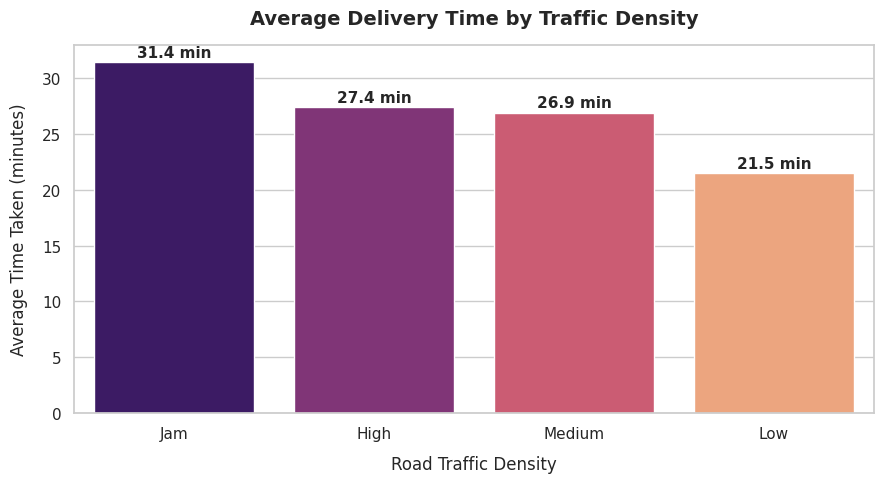

In [28]:
# Clean figure setup
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Sort traffic density order
traffic_order = df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values(ascending=False).index

# Plot Bar Chart (hue parameter set to avoid Seaborn warning)
ax = sns.barplot(
    data=df,
    x='Road_traffic_density',
    y='Time_taken (min)',
    order=traffic_order,
    hue='Road_traffic_density',
    palette='magma',
    legend=False,
    errorbar=None
)

# Formatting title & labels
plt.title('Average Delivery Time by Traffic Density', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Road Traffic Density', fontsize=12, labelpad=10)
plt.ylabel('Average Time Taken (minutes)', fontsize=12, labelpad=10)

# Add numeric values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} min',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Chart 2**: Scatter Plot - Distance vs. Delivery Time

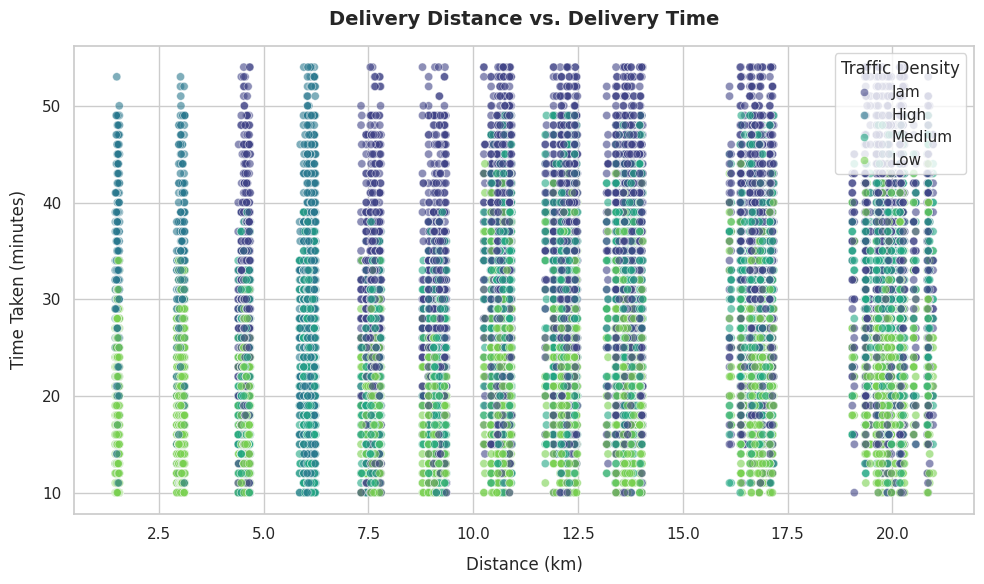

In [29]:
# Clean figure setup
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot Scatter Plot safely
sns.scatterplot(
    data=df,
    x='distance_km',
    y='Time_taken (min)',
    hue='Road_traffic_density',
    palette='viridis',
    alpha=0.6,
    s=35
)

# Formatting title & labels
plt.title('Delivery Distance vs. Delivery Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distance (km)', fontsize=12, labelpad=10)
plt.ylabel('Time Taken (minutes)', fontsize=12, labelpad=10)
plt.legend(title='Traffic Density', loc='upper right')

plt.tight_layout()
plt.show()

#**STEP # 8 Business Insights & Recommendations**

### 1. High Traffic Impact on Delivery Performance
* **Finding:** Delivery times increase significantly (up to ~31.4 minutes) during Jam and High traffic conditions compared to Low traffic (~21.5 minutes).
* **Business Implication:** Traffic is the primary bottleneck for on-time deliveries. The business should dynamically adjust estimated delivery times (EDTs) during peak hours, optimize route navigation, or incentivize delivery drivers using two-wheelers/bikes in high-traffic zones to navigate congestion faster.

### 2. Distance-Independent Delivery Bottlenecks
* **Finding:** Long delivery distances show a weak direct correlation with total time, indicating that urban delays (traffic jams, order preparation time at restaurants) impact delivery duration more than physical distance.
* **Business Implication:** The business should focus on reducing restaurant prep times and optimizing order dispatch logic rather than restricting delivery radius, as distance alone is not the sole cause of delays.

### 3. Cumulative Delay in Adverse Weather and Heavy Traffic
* **Finding:** The combination of bad weather conditions (e.g., Foggy/Stormy) and high traffic density results in the highest average delivery time (~35+ minutes).
* **Business Implication:** During severe weather and high traffic, customer satisfaction drops due to delayed orders. The business should implement bad-weather surcharges (to fairly compensate riders) and temporarily shrink the delivery radius to ensure safety and reasonable delivery times.

# **STEP # 9  AI explanation (GROQ API - Working)**

In [40]:
# 1. Install Groq Library
!pip install -q groq

import os
from google.colab import userdata
from groq import Groq

# 2. Safely read API Key from Colab Secrets
groq_api_key = userdata.get('GROQ_API_KEY')
client = Groq(api_key=groq_api_key)

# 3. Create prompt with calculated results
prompt_text = f"""
You are a senior business analyst. Explain these food delivery findings in 3 short, easy bullet points for business owners:
- Total Deliveries: {total_deliveries:,}
- Average Delivery Time: {avg_delivery_time:.2f} mins (Worst in Jam/High traffic: {q1_highest_time:.2f} mins)
- Average Speed & Distance: {avg_speed:.2f} km/h across {avg_distance:.2f} km average distance
- Worst Condition: {q3_worst_combo[0]} weather with {q3_worst_combo[1]} traffic ({q3_worst_combo_time:.2f} mins)
"""

# 4. Call Groq API with current active model
response = client.chat.completions.create(
    messages=[
        {"role": "system", "content": "You provide very short, easy-to-understand business advice."},
        {"role": "user", "content": prompt_text}
    ],
    model="openai/gpt-oss-20b",
)

In [43]:
from IPython.display import Markdown, display

# Get AI response text
ai_output = response.choices[0].message.content

# Display it as styled Markdown with a nice heading
display(Markdown(f"""
##  AI-Generated Business Explanation
*(Powered by Groq — Llama/GPT-OSS Model)*

---

{ai_output}

---
"""))


##  AI-Generated Business Explanation
*(Powered by Groq — Llama/GPT-OSS Model)*

---

- **High volume but slow service** – 38,964 deliveries with an average 26.6‑minute wait, hitting 31.4 min during peak traffic.  
- **Speed‑distance balance** – couriers travel ~9.8 km each trip at an average 23.6 km/h, showing room to tighten route planning.  
- **Weather‑traffic combo hurts** – fog + jam traffic tops out at 36.9 min; consider weather‑based dispatch or extra drivers during foggy rushes.

---


In [44]:
from IPython.display import HTML, display

ai_output = response.choices[0].message.content

html_content = f"""
<div style="background-color:#f0f8ff; border-left: 6px solid #1E88E5; padding: 20px; border-radius: 10px; font-family: Arial; margin-top: 10px;">
    <h3 style="color:#1E88E5;"> AI-Generated Business Explanation</h3>
    <p style="color:#555; font-size: 13px;"><i>Powered by Groq (Llama/GPT-OSS Model)</i></p>
    <hr style="border: 1px solid #ddd;">
    <div style="font-size: 15px; color:#333; line-height: 1.6; white-space: pre-line;">
        {ai_output}
    </div>
</div>
"""

display(HTML(html_content))

# **STEP # 10 Project Summary & Conclusion**

* **Problem:** Food delivery performance faces operational delays due to unpredictable urban traffic, weather conditions, and prep times.
* **Approach:** Analyzed 38,964 delivery records using Pandas for data cleaning and statistics, built Matplotlib/Seaborn visualizations, and integrated Groq Llama AI for business reporting.
* **Results:** Identified traffic jams as the primary bottleneck (~31.4 min avg delivery time) and bad-weather + traffic combination as the peak delay scenario (~35+ mins).
* **Improvements:** Implement dynamic ETA adjustments during peak rush hours, optimize restaurant dispatch workflows, and introduce bad-weather delivery surcharges.